In [1]:
import sys
sys.path.append('src')
from satpos import *
from RINEX import *
from sppp import *
from lambda_common import *
from brdc_pro import *

### This is a Jupyter Notebook of single-frequency RTK (SF-RTK) of Easy4RTK, including RTK processing, results saving and visualization.   

In [2]:
def reconstruct_obs_mat(obs_mat):
    #函数: 重整有效观测数据字典(根据Epoch_OK标识)
    #输入: 有效观测数据字典
    #输出: 重整后的观测数据字典
    r_obsmat=[]
    for i in range(len(obs_mat)):
        if(obs_mat[i][0]['Epoch_OK'])!=0:
            continue
        else:
            r_obsmat.append(obs_mat[i])
    #返回观测数据字典
    return r_obsmat

#单频周跳探测方法实现
#周跳探测
def get_phase_jump_SF(p1,l1,Mw_sign,Mw_threshold,f1=1575.42*1e6):    
    clight=satpos.clight
    slip=0
    
    #如果无观测值, 则返回0
    if(p1==0.0 or l1==0.0):
        return 0.0,0,0.0,0.0

    #单频Mw组合探测小周跳
    lambda_1=clight/f1
    m1=l1*lambda_1-p1   #相位-码= N+2Ion
    m0=Mw_sign
    Mw_sign=m1#更新Mw组合观测值    
    
    if(m0!=0.0 and abs(m1-m0)>Mw_threshold):
        slip=1

    #周跳修复(单频无法确定周跳大小)
    dN1,dN2=0.0,0.0

    return Mw_sign,slip,dN1,dN2

def update_phase_slip_SF(obslist,Mw_sign,slip_sign,Mw_threshold,f1,dN=[],dN_fix_mode=0):
    #首先清空周跳标志
    for i in range(len(slip_sign)):
        slip_sign[i]=0
    
    #清空无观测值的周跳检测量
    prns=[int(t['PRN'][1:]) for t in obslist]
    for i in range(len(GF_sign)):
        in_PRN=i+1
        if(in_PRN not in prns):
            GF_sign[i]=0.0
            Mw_sign[i]=0.0
    
    #周跳检测
    sat_num=len(obslist)
    
    for i in range(sat_num):
        si_PRN=obslist[i]['PRN']
        PRN_index=int(si_PRN[1:])-1
        
        p1=obslist[i]['OBS'][0]
        l1=obslist[i]['OBS'][1]
        # p2=obslist[i]['OBS'][5]
        # l2=obslist[i]['OBS'][6]

        Mw,slip,dN1,dN2=get_phase_jump_SF(p1,l1,Mw_sign[PRN_index],Mw_threshold,f1=f1)
        if(slip):
            #print('{} Phase Jump occurs -- Mw:{}->{} p1:{} l1:{} dN1:{}'.format(si_PRN,Mw_sign[PRN_index],Mw,p1,l1,dN1))
            pass
        Mw_sign[PRN_index]=Mw
        slip_sign[PRN_index]=slip
        
        if(dN_fix_mode):
            dN[PRN_index][0]=dN1
            dN[PRN_index][1]=dN2
    
    return Mw_sign,slip_sign,dN

### 1. The block below is configurations of Easy4RTK-SF-RTK mode

In [3]:
#首先读取观测值(以RINEX后处理文件模型为例)
base_path='data/OBS/WUH2/wuh21310.23o'
base_pos=[-2267750.2791772727, 5009154.5868055085, 3221294.42165066]
rove_path='data/OBS/JFNG/jfng1310.23o'
obs_type=['C2I','L2I','D2I','S2I','XXX','XXX','XXX','XXX']
obs_sys='C'

dy_mode='static'

eph_path='data/BRDC/brdc1310.23p'

eph_mode='brdc'
clk_mode='brdc'

el_threthod=10.0
ex_threshold_v=30.0
exthreshold_v_sigma=4.0
dsnr_threshold=5.0

GF_threshold=0.15
Mw_threshold=2.5
out_age=31

f1=1561.098e6
f2=0e6

freqs=[[f1,f2]]      #频率
epoch_start=0        #开始解算历元序号
epoch_length=2880    #总解算历元数
AMB_FIX=1            #模糊度固定

sat_out=["C{:02d}".format(t) for t in range(1,6)]+["C{:02d}".format(t) for t in range(59,66)]

#广播星历读取
ion_parmas_GPSK,GPS_eph=BRDC2GPSEPH(eph_path)
ion_parmas_BDSK,BDS_eph=BRDC2BDSEPH(eph_path)
ion_parmas_GAL,GAL_eph=BRDC2GALEPH(eph_path)

ion_param=ion_parmas_GPSK

#观测值读取与重整
#读取
base_obs_mats=reconstruct_obs_mat(RINEX3_to_obsmat(base_path,obs_type,sys=obs_sys,f1=f1,f2=f2))
base_time_list=[t[0]['GPSsec'] for t in base_obs_mats]
rove_obs_mats=reconstruct_obs_mat(RINEX3_to_obsmat(rove_path,obs_type,sys=obs_sys,f1=f1,f2=f2))
rove_time_list=[t[0]['GPSsec'] for t in rove_obs_mats]
#重整
br_obs_mats=[]
for i in range(len(rove_time_list)):
    br_obs_mats.append([[],[]]) 
    try:
        id_base=base_time_list.index(rove_time_list[i])
    except:
        continue
    br_obs_mats[-1][0]=base_obs_mats[id_base].copy()
    br_obs_mats[-1][1]=rove_obs_mats[i].copy()
#清除旧观测矩阵以节省空间
del base_obs_mats
del rove_obs_mats

No XXX
No XXX
No XXX
No XXX
No XXX
No XXX
No XXX
No XXX


### 2. The blocks below are used as the main processing of SF-RTK

In [4]:
def update_sd_amb(p_b,l_b,p_r,l_r,f):
    #站间单差模糊度初始化
    if(p_b==0.0 or l_b==0.0 or p_r==0.0 or l_r==0.0):
        return 0.0
    #初始化站间单差模糊度(单位为周cycle)
    cp,pr=l_b-l_r,p_b-p_r
    return cp-pr*f/clight


def init_RTK(base_pos,br_obs_mats,index,f1,f2,sys='G',eph_mode="brdc",spp_brdc=[],brdc_obs=[]):
    #首先初始化流动站位置
    if(eph_mode=='brdc'):
        rove_rr,rove_obs=spp_brdc.copy(),brdc_obs.copy()
        rove_prns=[t['PRN'] for t in rove_obs]
        base_prns=[t['PRN'] for t in br_obs_mats[index][0][1]]
    else:
        return False
    rt_week=br_obs_mats[index][1][0]['GPSweek']
    rt_sec=br_obs_mats[index][1][0]['GPSsec']
    rt_unix=gpst2time(rt_week,rt_sec)
    #根据流动站位置初始化状态向量的基线部分
    dx,dy,dz=rove_rr[0]-base_pos[0],rove_rr[1]-base_pos[1],rove_rr[2]-base_pos[2]
    #根据双频观测值初始化站间单差模糊度
    sys_index=['G','C','E']
    sys_sat_nums=[32,65,37]
    sys_sat_num=sys_sat_nums[sys_index.index(sys)]
    X=np.zeros((5+3*sys_sat_num,1),dtype=np.float64)
    Pk=np.zeros((5+3*sys_sat_num,5+3*sys_sat_num),np.float64)
    Qk=np.zeros((5+3*sys_sat_num,5+3*sys_sat_num),np.float64)
    X_time=np.zeros((5+3*sys_sat_num,1))
    X[0][0],X[1][0],X[2][0]=rove_rr[0],rove_rr[1],rove_rr[2]#扩展卡尔曼滤波, 直接给出流动站位置
    Pk[0][0],Pk[1][1],Pk[2][2]=30*30,30*30,30*30
    X_time[0][0],X_time[1][0],X_time[2][0]=rt_unix,rt_unix,rt_unix
    #逐卫星遍历站间单差模糊度状态初值(dN1)
    for i in range(sys_sat_num):
        prn=sys+"{:02d}".format(i+1)
        if(prn not in rove_prns or prn not in base_prns):
            #如果未共视该卫星, 则跳过初始化
            continue
        prn_id_base=base_prns.index(prn)
        prn_id_rove=rove_prns.index(prn)
        p_b=br_obs_mats[index][0][1][prn_id_base]['OBS'][0]
        p_r=rove_obs[prn_id_rove]['OBS'][0]
        l_b=br_obs_mats[index][0][1][prn_id_base]['OBS'][1]
        l_r=rove_obs[prn_id_rove]['OBS'][1]
        sdamb=update_sd_amb(p_b,l_b,p_r,l_r,f1)
        if(sdamb!=0.0):
            X[5+sys_sat_num+i][0]=sdamb
            Pk[5+sys_sat_num+i][5+sys_sat_num+i]=30*30
            X_time[5+sys_sat_num+i][0]=rt_unix
    #逐卫星遍历站间单差模糊度状态初值(dN2)
    for i in range(sys_sat_num):
        prn=sys+"{:02d}".format(i+1)
        if(prn not in rove_prns or prn not in base_prns):
            #如果未共视该卫星, 则跳过初始化
            continue
        prn_id_base=base_prns.index(prn)
        prn_id_rove=rove_prns.index(prn)
        p_b=br_obs_mats[index][0][1][prn_id_base]['OBS'][5]
        p_r=rove_obs[prn_id_rove]['OBS'][5]
        l_b=br_obs_mats[index][0][1][prn_id_base]['OBS'][6]
        l_r=rove_obs[prn_id_rove]['OBS'][6]
        sdamb=update_sd_amb(p_b,l_b,p_r,l_r,f2)
        if(sdamb!=0.0):
            X[5+2*sys_sat_num+i][0]=sdamb
            Pk[5+2*sys_sat_num+i][5+2*sys_sat_num+i]=30*30
            X_time[5+2*sys_sat_num+i][0]=rt_unix
    
    #周跳检验量(每历元均更新)
    GF_sign=np.zeros((sys_sat_num),dtype=np.float64)
    Mw_sign=np.zeros((sys_sat_num),dtype=np.float64)
    #周跳标志(每历元均重置为0)
    slip_sign=np.zeros((sys_sat_num),dtype=int)
    #周跳修复累计列表(随状态初始化重置)
    dN_sign=np.zeros((sys_sat_num,2),dtype=np.float64)
    
    return X,X_time,Pk,Qk,GF_sign,Mw_sign,slip_sign,dN_sign

def select_ddsat(br_obs_mats,index,base_pos,rove_pos,rt_unix,f1,f2,rove_obs,base_satpos_pre={},rove_satpos_pre={},dsnr_threshold=None,GPS_eph=[],BDS_eph=[],GAL_eph=[],rover_obs_pre=[]):
    #以流动站为基准,创建站间单差观测矩阵(同时消去卫星钟差、ZHD和卫地距项, 原因为预留电离层项) 
    OMGE=7.2921151467E-5
    rnx_sdobs=[]
    base_prns=[t['PRN'] for t in br_obs_mats[index][0][1]]
    rove_prns=[t['PRN'] for t in br_obs_mats[index][1][1]]
    rove_obs_prns=[t['PRN'] for t in rove_obs]
    base_satpos={}
    for prn in rove_prns:
        if(prn not in rove_obs_prns):
            continue
        try:
            id_base=base_prns.index(prn)
        except:
            continue
        id_rove=rove_prns.index(prn)
        sdobs=[0.0,0.0,0.0,0.0,0.0,
               0.0,0.0,0.0,0.0,0.0]
        #循环构建站间单差观测值(无值不单差)
        sat_use_sign=1
        for obs in range(5):
            if(br_obs_mats[index][0][1][id_base]['OBS'][obs]!=0.0 and br_obs_mats[index][1][1][id_rove]['OBS'][obs]!=0.0):
                if(obs==0 or obs==5):
                    #伪距观测值的计算值
                    p_b=br_obs_mats[index][0][1][id_base]['OBS'][obs]#基准站伪距
                    if(base_satpos_pre=={}):
                        #广播星历计算卫星位置
                        if(prn[0]=='G'):
                            rs_info=GPSEPH2Satpos(GPS_eph,rt_unix,prn,rho=p_b)
                            rs_b,dts_b=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                        if(prn[0]=='C'):
                            rs_info=BDSEPH2SatPos(BDS_eph,rt_unix,prn,rho=p_b)
                            rs_b,dts_b=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                        if(prn[0]=='E'):
                            rs_info=GALEPH2Satpos(GAL_eph,rt_unix,prn,rho=p_b)
                            rs_b,dts_b=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                    else:
                        rs_b,dts_b=base_satpos_pre[prn],base_satpos_pre[prn][3]
                    r0_b=sqrt( (rs_b[0]-base_pos[0])*(rs_b[0]-base_pos[0])+(rs_b[1]-base_pos[1])*(rs_b[1]-base_pos[1])+(rs_b[2]-base_pos[2])*(rs_b[2]-base_pos[2]) )
                    r0_b=r0_b+OMGE*(rs_b[0]*base_pos[1]-rs_b[1]*base_pos[0])/clight
                    Mh,_=NMF(base_pos,rs_b,rt_unix)
                    zhd=get_Trop_delay_dry(base_pos)
                    p_b_osr=p_b-(r0_b+Mh*zhd-clight*dts_b)#基准站伪距的计算值
                    base_satpos[prn]=[rs_b[0],rs_b[1],rs_b[2],dts_b,rs_b[3],rs_b[4],rs_b[5],999.0]

                    p_r=br_obs_mats[index][1][1][id_rove]['OBS'][obs]#流动站伪距
                    if(rove_satpos_pre=={}):
                       #广播星历计算卫星位置
                        if(prn[0]=='G'):
                            rs_info=GPSEPH2Satpos(GPS_eph,rt_unix,prn,rho=p_r)
                            rs_r,dts_r=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                        if(prn[0]=='C'):
                            rs_info=BDSEPH2SatPos(BDS_eph,rt_unix,prn,rho=p_r)
                            rs_r,dts_r=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                        if(prn[0]=='E'):
                            rs_info=GALEPH2Satpos(GAL_eph,rt_unix,prn,rho=p_r)
                            rs_r,dts_r=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                    else:
                        rs_r,dts_r=rove_satpos_pre[prn],rove_satpos_pre[prn][3]
                    r0_r=sqrt( (rs_r[0]-rove_pos[0])*(rs_r[0]-rove_pos[0])+(rs_r[1]-rove_pos[1])*(rs_r[1]-rove_pos[1])+(rs_r[2]-rove_pos[2])*(rs_r[2]-rove_pos[2]) )
                    r0_r=r0_r+OMGE*(rs_r[0]*rove_pos[1]-rs_r[1]*rove_pos[0])/clight
                    Mh,_=NMF(rove_pos,rs_r,rt_unix)
                    zhd=get_Trop_delay_dry(rove_pos)
                    p_r_osr=p_r-(r0_r+Mh*zhd-clight*dts_r)#流动站伪距的计算值
                    sdobs[obs]=p_b_osr-p_r_osr#伪距站间单差
                elif(obs==1 or obs==6):
                    #载波相位观测值的频率确定
                    if(obs==1):
                        f=f1
                    if(obs==6):
                        f=f2
                    #载波相位观测值的站间单差
                    l_b=clight/f*br_obs_mats[index][0][1][id_base]['OBS'][obs]#基准站载波相位
                    Mh,_=NMF(base_pos,rs_b,rt_unix)
                    zhd=get_Trop_delay_dry(base_pos)
                    l_b_osr=l_b-(r0_b+Mh*zhd-clight*dts_b)           #基准站载波相位的计算值

                    l_r=clight/f*br_obs_mats[index][1][1][id_rove]['OBS'][obs]#流动站载波相位
                    Mh,_=NMF(rove_pos,rs_r,rt_unix)
                    zhd=get_Trop_delay_dry(rove_pos)
                    l_r_osr=l_r-(r0_r+Mh*zhd-clight*dts_r)#流动站伪距的计算值
                    sdobs[obs]=l_b_osr*f/clight-l_r_osr*f/clight#载波相位间单差
                else:#其余导航状态直接单差(引入站间单差模型, 考虑一种新的基于dSNR的站间单差模型)
                    sdobs[obs]=br_obs_mats[index][0][1][id_base]['OBS'][obs]-br_obs_mats[index][1][1][id_rove]['OBS'][obs]
            #观测值有效性校验
            if(obs in [0,1,5,6] and (br_obs_mats[index][0][1][id_base]['OBS'][obs]==0.0 or br_obs_mats[index][1][1][id_rove]['OBS'][obs]==0.0)):
                sat_use_sign=0
            #单差SNR掩码模型有效性
            if(dsnr_threshold!=None and obs in [4,9] and abs(sdobs[obs])>dsnr_threshold):
                sat_use_sign=0
        if(sat_use_sign):
            rnx_sdobs.append({'PRN':prn,'OBS':sdobs.copy()})
    return rnx_sdobs,base_satpos

def update_RTK_state(base_pos,spp_rr,epoch,rt_unix,rnx_sdobs,X,X_time,Pk,Qk,GF_sign,Mw_sign,slip_sign,dN_sign,out_age,Mw_threshold,GF_threshold,dy_mode,f1,f2):
    #首历元, 跳过状态更新
    if(not epoch):
        return 
    #提取卫星系统总卫星数量
    sat_num=round((len(X)-5)/3)
    #基线向量状态更新
    if(dy_mode=='static'):
        #静态, 无过程噪声
        Qk[0][0],Qk[1][1],Qk[2][2]=0.0,0.0,0.0
    else:
        #动态, 有过程噪声
        X[0][0],X[1][0],X[2][0]=spp_rr[0],spp_rr[1],spp_rr[2]
        Qk[0][0],Qk[1][1],Qk[2][2]=30*30,30*30,30*30

    #N1单差模糊度状态更新
    for j in range(5+sat_num,5+2*sat_num):
        dt=rt_unix-X_time[j][0]
        si_PRN=j-(5+sat_num)+1#整型PRN序号(PRN-1)
        rnx_obs_prns=[int(t['PRN'][1:]) for t in rnx_sdobs]#观测列表中的整型PRN序号
        if(si_PRN in rnx_obs_prns and dt<=out_age):
            Qk[j][j]=0e-8*dt#模糊度(常数)
        if(si_PRN in rnx_obs_prns and dt>out_age):
            if(dt>out_age):
                GF_sign[si_PRN-1]=0.0
                Mw_sign[si_PRN-1]=0.0
            sdp1=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][0]
            sdl1=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][1]
            X[j][0]=sdl1-sdp1*f1/clight
            Qk[j][j]=30*30
            Pk[j,:]=0.0 
            Pk[:,j]=0.0 
    #组合观测值周跳探测
    Mw_sign,slip_sign,dN_sign=update_phase_slip_SF(rnx_sdobs,Mw_sign,slip_sign,Mw_threshold,f1,dN_sign)
    for j in range(len(slip_sign)):
        #发生了周跳, 更新两个频率上的模糊度状态和过程噪声
        if(slip_sign[j] and (abs(dN_sign[j][0])>=0.0 or abs(dN_sign[j][1]>=0.0))):
            si_PRN=j+1
            rnx_obs_prns=[int(t['PRN'][1:]) for t in rnx_sdobs]
            sdp1=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][0]
            sdp2=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][5]
            sdl1=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][1]
            sdl2=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][6]
            X[5+sat_num+j][0]=sdl1-sdp1*f1/clight
            X[5+2*sat_num+j][0]=sdl2-sdp2*f2/clight
            Qk[5+sat_num+j][5+sat_num+j]=30*30                
            Qk[5+2*sat_num+j][5+2*sat_num+j]=30*30
            
            Pk[5+sat_num+j,:]=0.0#状态方差协方差重置
            Pk[:,5+sat_num+j]=0.0
            Pk[5+2*sat_num+j,:]=0.0
            Pk[:,5+2*sat_num+j]=0.0
    #连续弧段载波相位offset校正
    offset,offset_j,offset_ids=0.0,0,[]
    for j in range(len(slip_sign)):
        #无周跳, 未重置的模糊度状态与当前历元的原始双差模糊度间求差
        if(not slip_sign[j] and X[5+sat_num+j]!=0.0 and Qk[5+sat_num+j][5+sat_num+j]!=30*30 and Qk[5+sat_num+j][5+sat_num+j]!=0.0):
            #原始观测值计算单差模糊度
            si_PRN=j+1
            rnx_obs_prns=[int(t['PRN'][1:]) for t in rnx_sdobs]
            if(si_PRN not in rnx_obs_prns):
                continue
            sdp1=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][0]
            sdp2=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][5]
            sdl1=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][1]
            sdl2=rnx_sdobs[rnx_obs_prns.index(si_PRN)]['OBS'][6]
            bias_p_l=sdl1-sdp1*f1/clight
            offset+=bias_p_l-X[5+sat_num+j][0]
            offset_j+=1
            offset_ids.append(j)
    if(offset_j):
        doffset=offset/offset_j
        for j in offset_ids:
            X[5+sat_num+j][0]+=doffset
        

def createRTK_HRZ(rnx_sdobs,base_pos,X,rt_unix,base_satpos,f1=1575.42*1e6,f2=1227.60*1e6,ex_threshold_v=30,exthreshold_v_sigma=4,post=False):
    #初始化卫星数量
    sat_num=len(rnx_sdobs)
    sys_sat_sum=round((X.shape[0]-5)/3)
    sat_out=[]
    sat_out_post=[]
    #光速, GPS系统维持的地球自转角速度(弧度制)
    clight=2.99792458e8
    OMGE=7.2921151467E-5
    #流动站坐标、接收机钟差
    #rr=np.array([X[0],X[1],X[2],X[3]]).reshape(4)
    #基准站坐标
    rr=[0.0,0.0,0.0]
    rr[0]=base_pos[0]
    rr[1]=base_pos[1]
    rr[2]=base_pos[2]
    #地球固体潮汐坐标改正(严格来说,该项在站间单差中被近似消除)
    #参考星选择
    el_max,el_max_id,el_scan_id=0,999,0
    for sat in [t['PRN'] for t in rnx_sdobs]:
        _,el=getazel(base_satpos[sat],[rr[0],rr[1],rr[2]])
        if(el>el_max):
            el_max=el
            el_max_id=el_scan_id
        el_scan_id+=1
    #创建设计矩阵和观测值矩阵(RTK基本双差观测模型,: 状态维数3+2n, 观测维数: 4(n-1) )
    H=np.zeros((2*sat_num-2,3+sat_num),dtype=np.float64)#设计矩阵
    R=np.zeros((2*sat_num-2,2*sat_num-2),dtype=np.float64)#观测方差
    Z=np.zeros((2*sat_num-2,1),dtype=np.float64)          #观测矩阵
    Z_scan_count=0
    #单卫星四行矩阵创建与校区
    for i in range(len(rnx_sdobs)):
        #如果为参考星, 跳过
        if(i==el_max_id):
            continue
        #PRN号识别
        si_PRN=rnx_sdobs[i]["PRN"]
        si_PRN_ref=rnx_sdobs[el_max_id]['PRN']
        #N1单差模糊度索引(请注意模糊度索引与观测模型不同)
        N1_idx=5+sys_sat_sum+int(si_PRN[1:])-1
        N2_idx=5+2*sys_sat_sum+int(si_PRN[1:])-1
        N1_ref_idx=5+sys_sat_sum+int(si_PRN_ref[1:])-1
        N2_ref_idx=5+2*sys_sat_sum+int(si_PRN_ref[1:])-1
        #几何距离计算
        rs=base_satpos[si_PRN]
        rs_ref=base_satpos[rnx_sdobs[el_max_id]['PRN']]
        r0=sqrt( (rs[0]-rr[0])*(rs[0]-rr[0])+(rs[1]-rr[1])*(rs[1]-rr[1])+(rs[2]-rr[2])*(rs[2]-rr[2]) )
        r0_ref=sqrt( (rs_ref[0]-rr[0])*(rs_ref[0]-rr[0])+(rs_ref[1]-rr[1])*(rs_ref[1]-rr[1])+(rs_ref[2]-rr[2])*(rs_ref[2]-rr[2]) )
        #单差方向余弦向量计算
        urs_dx=-(rr[0]-rs[0])/r0+(rr[0]-rs_ref[0])/r0_ref
        urs_dy=-(rr[1]-rs[1])/r0+(rr[1]-rs_ref[1])/r0_ref
        urs_dz=-(rr[2]-rs[2])/r0+(rr[2]-rs_ref[2])/r0_ref
        #p1双差伪距法方程
        H_sub_1=np.zeros(3+sat_num,dtype=np.float64)
        H_sub_1[:3]=[urs_dx,urs_dy,urs_dz]
        #l1双差相位法方程
        H_sub_2=np.zeros(3+sat_num,dtype=np.float64)
        H_sub_2[:3]=[urs_dx,urs_dy,urs_dz]
        H_sub_2[3+i]=clight/f1
        H_sub_2[3+el_max_id]=-clight/f1#模糊度的星间双差项系数
        #设计矩阵
        H[Z_scan_count*2]=H_sub_1
        H[Z_scan_count*2+1]=H_sub_2
        #残差向量(双差观测值,单位为m)
        Z[Z_scan_count*2]=rnx_sdobs[i]['OBS'][0]-rnx_sdobs[el_max_id]['OBS'][0]
        Z[Z_scan_count*2+1]=clight/f1*(rnx_sdobs[i]['OBS'][1]-rnx_sdobs[el_max_id]['OBS'][1])
        Z[Z_scan_count*2+1]-=(clight/f1*X[N1_idx]-clight/f1*X[N1_ref_idx])
        # #流动站观测噪声(随机模型)
        _,el=getazel(rs,rr)                                           #流动站卫星高度角
        _,el_ref=getazel(rs_ref,rr)                                   #流动站参考卫星高度角
        var=0.003*0.003+0.003*0.003/sin(el)/sin(el)                   #流动站载波相位噪声
        var_ref=0.003*0.003+0.003*0.003/sin(el_ref)/sin(el_ref)       #流动站参考卫星载波相位噪声
        #基准站观测噪声(随机模型)
        _,el_b=getazel(rs,base_pos)                                   #基准站卫星高度角
        _,el_b_ref=getazel(rs_ref,base_pos)                           #基准站参考卫星高度角
        var_b=0.003*0.003+0.003*0.003/sin(el_b)/sin(el_b)             #基准站载波相位噪声
        var_b_ref=0.003*0.003+0.003*0.003/sin(el_b_ref)/sin(el_b_ref) #基准站参考卫星载波相位噪声
        # #双差随机模型
        R[Z_scan_count*2][Z_scan_count*2]=100*100*(var+var_ref+var_b+var_b_ref)
        R[Z_scan_count*2+1][Z_scan_count*2+1]=var+var_ref+var_b+var_b_ref
        #验前残差粗差识别
        if(post==False):
            if(abs(Z[Z_scan_count*2])>ex_threshold_v or abs(Z[Z_scan_count*2+1])>ex_threshold_v):
                #非首历元粗差剔除
                #print("去除粗差前观测列表: ", obslist)
                sat_out.append(i)#注意: 此处必须添加观测列表中的id索引             
        #验后方差校验
        if(post==True):
            out_v=[]
            if abs(Z[Z_scan_count*2])>exthreshold_v_sigma*sqrt(R[Z_scan_count*2][Z_scan_count*2]): 
                #print(si_PRN," 验后方差校验不通过",v[i*4],4*sqrt(R[i*4][i*4]))
                out_v.append(Z[Z_scan_count*2])
            if abs(Z[Z_scan_count*2+1])>exthreshold_v_sigma*sqrt(R[Z_scan_count*2+1][Z_scan_count*2+1]):
                #print(si_PRN," 验后方差校验不通过",v[i*4+1],4*sqrt(R[i*4+1][i*4+1]))
                out_v.append(Z[Z_scan_count*2+1])
            if(len(out_v)):
                out_v.append(i)
                sat_out_post.append(out_v)
        
        Z_scan_count+=1
    #循环结束, 处理验前/验后粗差
    #验前残差部分
    obslist_new=rnx_sdobs.copy()
    for s in sat_out:
        obslist_new.remove(rnx_sdobs[s])
    #验后残差部分
    if(post==True):
        #全部校验通过
        if(len(sat_out_post)==0):
            return "KF fixed", obslist_new,Z,el_max_id
        #找到最大残差值
        vmax=0.0
        v_out=0
        for s in sat_out_post:
            for v_i in range(0,len(s)-1):
                if(abs(s[v_i])>vmax):
                    v_out=s[-1]
                    vmax=s[v_i]
        obslist_new.remove(rnx_sdobs[v_out])
        return "KF fixing", obslist_new,Z,el_max_id
    return H,R,Z,obslist_new

def createRTK_XkPkQk(rnx_sdobs,X,Pk,Qk):
    #系统模型构建
    #输入: 观测字典列表, 全局状态X, 全局方差Pk, 全局过程噪声Qk
    #输出: 滤波状态t_Xk, 滤波方差t_Pk, 滤波过程噪声t_Qk
    sat_num=len(rnx_sdobs)#本历元有效观测卫星数量
    sys_sat_sum=round((X.shape[0]-5)/3)#全局状态卫星数量
    
    #本历元更新状态所用系统临时变量(依据: 在观测列表内的卫星数量)
    t_Xk=np.zeros((sat_num+3,1),dtype=np.float64)
    t_Pk=np.zeros((sat_num+3,sat_num+3),dtype=np.float64)
    t_Qk=np.zeros((sat_num+3,sat_num+3),dtype=np.float64)
    
    #有效卫星索引(计算本历元有效卫星各状态量在总状态中的索引)
    sat_use=[]#首先保证不变状态量保存在内
    for i in range(len(rnx_sdobs)):
        si_PRN=rnx_sdobs[i]['PRN']
        PRN_index=int(si_PRN[1:])-1
        sat_use.append(PRN_index)
    index_use=[0,1,2]#基础导航状态
    for s in sat_use:
        index_use.append(5+sys_sat_sum+s)   #L1模糊度状态导入
    # for s in sat_use:
    #     index_use.append(5+2*sys_sat_sum+s) #L2模糊度状态导入
    
    #系统状态,方差,过程噪声赋值
    for i in range(3+sat_num):
        t_Xk[i]=X[index_use[i]]                         #系统状态
        t_Qk[i][i]=Qk[index_use[i]][index_use[i]]       #系统过程噪声
        for j in range(3+sat_num):
            t_Pk[i][j]=Pk[index_use[i]][index_use[j]]   #系统方差
    
    #返回系统模型各临时矩阵
    return t_Xk,t_Pk,t_Qk

def updateRTK_XkPkQk(rnx_sdobs,rt_unix,t_Xk,t_Pk,t_Qk,X,Pk,Qk,X_time):
    #系统模型恢复与更新
    #输入: 观测字典列表, 滤波状态t_Xk, 滤波方差t_Pk, 滤波过程噪声t_Qk, 全局状态X, 全局方差Pk, 全局过程噪声Qk
    #输出: 恢复并更新后的全局状态X, 全局方差Pk, 全局过程噪声Qk
    sat_num=len(rnx_sdobs)#本历元有效观测卫星数量
    sys_sat_sum=round((X.shape[0]-5)/3)#全局状态卫星数量
    
    #本历元更新状态所用系统临时变量(不能占用全局状态储存空间)
    t_X=np.zeros((3*sys_sat_sum+5,1),dtype=np.float64)
    t_X_time=np.zeros(3*sys_sat_sum+5,dtype=np.float64)
    t_P=np.zeros((3*sys_sat_sum+5,3*sys_sat_sum+5),dtype=np.float64)
    t_Q=np.zeros((3*sys_sat_sum+5,3*sys_sat_sum+5),dtype=np.float64)
    #拷贝原值
    t_X=X.copy()
    t_X_time=X_time.copy()
    t_P=Pk.copy()
    t_Q=Qk.copy()
    
    #有效卫星索引(计算本历元有效卫星各状态量在总状态中的索引)
    sat_use=[]#首先保证不变状态量保存在内
    for i in range(len(rnx_sdobs)):
        si_PRN=rnx_sdobs[i]['PRN']
        PRN_index=int(si_PRN[1:])-1
        sat_use.append(PRN_index)
    index_use=[0,1,2]#基础导航状态
    for s in sat_use:
        index_use.append(5+sys_sat_sum+s)   #L1模糊度状态导入

    #系统状态,方差,过程噪声恢复更新
    for i in range(3+sat_num):
        t_X[index_use[i]]=t_Xk[i]                         #系统状态
        t_X_time[index_use[i]]=rt_unix                    #系统状态时标
        t_Q[index_use[i]][index_use[i]]=t_Qk[i][i]        #系统过程噪声
        for j in range(3+sat_num):
            if(i==j and t_Pk[i][j]<0.0):
                t_Pk[i][j]=30*30
            t_P[index_use[i]][index_use[j]]=t_Pk[i][j]   #系统方差
    #返回系统模型各全局矩阵
    return t_X,t_P,t_Q,t_X_time
def RTK_AR(rnx_sdobs,peph_sat_pos,Xk_dot,t_Pk,ratio_threshold=2.0):
    #从Pk和X中恢复整数部分
    Xfloat_N12=np.zeros((len(rnx_sdobs),1))
    Pfloat_N12=np.zeros((len(rnx_sdobs),len(rnx_sdobs)))
    lambda_trans=np.zeros((len(rnx_sdobs),len(rnx_sdobs)))
    #计算各卫星高度角,选择高度角最高的卫星为基准星准备进行星间单差
    el_max=0.0
    el_max_id=999
    for id in range(len(rnx_sdobs)):
        #计算高度角
        sat_xyzt=peph_sat_pos[rnx_sdobs[id]['PRN']]
        #读取模糊度状态的方差
        # tk_N1=t_Pk[5+len(rnx_sdobs)+id][5+len(rnx_sdobs)+id]
        # tk_N2=t_Pk[5+2*len(rnx_sdobs)+id][5+2*len(rnx_sdobs)+id]
        _,el=getazel(sat_xyzt,[X[0][0],X[1][0],X[2][0]])
        # if(tk_N1>2.25 or tk_N2>2.25):
        #     #模糊度状态在本历元重置, 不能作为参考星
        #     continue
        if(el>el_max):
            el_max=el
            el_max_id=id
    el_max_prn=rnx_sdobs[el_max_id]['PRN']
    for id in range(len(rnx_sdobs)):
        Xfloat_N12[id][0]=Xk_dot[3+id][0]
        Pfloat_N12[id]=t_Pk[3+id][3:]
        lambda_trans[id][id]=1.0
        lambda_trans[id][el_max_id]=-1.0#星间单差算子
    Xfloat_N12=lambda_trans.dot(Xfloat_N12)
    Pfloat_N12=lambda_trans.dot(Pfloat_N12).dot(lambda_trans.T)
    #构建星间单差模糊度矩阵
    X_float_N12_SD=[]
    id_use=[]
    #首先循环选择标准差小于1.5周的单差模糊度
    for id in range(len(Xfloat_N12)):
        if(id!=el_max_id and id!=len(rnx_sdobs)+el_max_id and Pfloat_N12[id][id]<2.25):
            #大于0.15周的模糊度不固定
            N_float_part=abs(round(Xfloat_N12[id][0])-Xfloat_N12[id][0])
            # if(N_float_part>0.15):
            #     continue
            X_float_N12_SD.append(Xfloat_N12[id])
            id_use.append(id)
    #如果无候选模糊度或候选模糊度过少, 则部分模糊度固定失败, 返回失败标志
    if(len(X_float_N12_SD)<3):
        return False
    P_float_N12_SD=[]
    for id in id_use:
        P_temp=[]
        for j_id in id_use:
            P_temp.append(Pfloat_N12[id][j_id])
        P_float_N12_SD.append(P_temp.copy())
    #如果位置内符合精度太差, 跳过模糊度固定
    # if(t_Pk[0][0]>0.25 or t_Pk[1][1]>0.25 or t_Pk[2][2]>0.25):
    #     return False
    X_float_N12_SD=np.array(X_float_N12_SD).reshape((len(X_float_N12_SD),1))
    try:
        #ratios,ds,N12_FIX=LAMBDA_FIX(Xfloat_N12,Pfloat_N12)
        ratios,ds,N12_FIX=LAMBDA_FIX(X_float_N12_SD,P_float_N12_SD)
        N12_FIX_res=(N12_FIX-X_float_N12_SD.T)
    except:
        ratios=[0.0,0.0]
        ds=[9999,9999]
    if(ratios[0]>ratio_threshold or ratios[1]>ratio_threshold):
        #单次模糊度固定ration校验通过
        #返回模糊度固定信息
        N12_SD_FIX_info={'ratios':[ratios[0],ratios[1]]}
        N12_SD_FIX_info['Ref_sat']=el_max_prn
        N12_SD_FIX_info['N12_SD_sat']=[]
        N12_SD_FIX_info['N12_SD_value']=[]
        for id in id_use:
            #L1频率上的星间单差模糊度
            if (id<len(rnx_sdobs)):
                N12_SD_FIX_info['N12_SD_sat'].append([rnx_sdobs[id]['PRN'],'N1'])
            #L2频率上的星间单差模糊度
            else:
                N12_SD_FIX_info['N12_SD_sat'].append([rnx_sdobs[id-len(rnx_sdobs)]['PRN'],'N2'])
            N12_SD_FIX_info['N12_SD_value'].append(N12_FIX[id_use.index(id)])
        return N12_SD_FIX_info
    else:
        #单次模糊度校验不通过, 进行部分模糊度固定(PAR)
        #方法一、依次剔除方差较大的模糊度
        if(len(X_float_N12_SD)==3):
            return False
        sub_id_use,t_ratios=PAR_Search(Xfloat_N12,Pfloat_N12,id_use)
        if(sub_id_use):
            #返回部分模糊度固定信息
            N12_SD_FIX_info={"ratios":[t_ratios[0],t_ratios[1]]}
            N12_SD_FIX_info['Ref_sat']=el_max_prn
            N12_SD_FIX_info['N12_SD_sat']=[]
            N12_SD_FIX_info['N12_SD_value']=[]
            for id in sub_id_use:
                #L1频率上的星间单差模糊度
                if (id<len(rnx_sdobs)):
                    N12_SD_FIX_info['N12_SD_sat'].append([rnx_sdobs[id]['PRN'],'N1'])
                #L2频率上的星间单差模糊度
                else:
                    N12_SD_FIX_info['N12_SD_sat'].append([rnx_sdobs[id-len(rnx_sdobs)]['PRN'],'N2'])
                N12_SD_FIX_info['N12_SD_value'].append(N12_FIX[id_use.index(id)])
            return N12_SD_FIX_info
        return False
    
def RTK_AR_FIX_HOLD(t_Xk,t_Pk,rnx_sdobs,Fix_info,X):
    #利用虚拟观测更新固定解
    #计算单系统卫星数量
    sys_sat_num=round((X.shape[0]-5)/3)
    prns=[t['PRN'] for t in rnx_sdobs]#获取本历元观测卫星的PRN顺序
    #添加固定解虚拟约束
    fix_value_count=0
    H=np.zeros( (len(Fix_info['N12_SD_sat']),len(t_Xk)) )   #虚拟设计矩阵维数: (固定模糊度行, 本历元状态量列)
    v=np.zeros( (len(Fix_info['N12_SD_sat']),1) )           #虚拟观测值维数: (固定模糊度行,1)
    R=np.zeros( (len(Fix_info['N12_SD_sat']),len(Fix_info['N12_SD_sat'])) )
    for fix in Fix_info['N12_SD_sat']:
        fix_prn=fix[0]
        fix_freq=int(fix[1][1:])-1                                      #计算模糊度频率所属
        ref_prn=Fix_info['Ref_sat']                                     #查找参考星
        sat_id=prns.index(fix_prn)                                      #在本历元观测序列中查找目标卫星位置
        ref_sat_id=prns.index(ref_prn)                                  #在本历元观测序列中查找参考卫星位置
        
        H[fix_value_count][3+sat_id]=1.0
        H[fix_value_count][3+ref_sat_id]=-1.0
        
        #计算模糊度单差的残差, 对残差向量添加一行
        float_v=X[5+sys_sat_num+fix_freq*sys_sat_num+int(fix_prn[1:])-1][0]-X[5+sys_sat_num+fix_freq*sys_sat_num+int(ref_prn[1:])-1][0]
        fix_v=round(Fix_info['N12_SD_value'][fix_value_count])-(float_v)
        v[fix_value_count][0]=fix_v #固定解约束
        R[fix_value_count][fix_value_count]=0.001 #虚拟方差
        fix_value_count+=1      #虚拟观测序号+1
    #1.状态一步预测
    X_up=t_Xk
    #2.状态一步预测误差
    Pk_1_k=t_Pk
    #3.滤波增益计算
    #Kk=(Pk_1_k.dot(H.T)).dot(inv((H.dot(Pk_1_k)).dot(H.T)+R))
    Kk=(Pk_1_k.dot(H.T)).dot(numba_inv((H.dot(Pk_1_k)).dot(H.T)+R))
    #滤波结果
    Xk_dot=X_up+Kk.dot(v)
    #滤波方差更新
    t_Pk=((np.eye(t_Xk.shape[0],dtype=np.float64)-Kk.dot(H))).dot(Pk_1_k)  
    t_Pk=t_Pk.dot((np.eye(t_Xk.shape[0],dtype=np.float64)-Kk.dot(H)).T)+Kk.dot(R).dot(Kk.T)
    t_Xk=Xk_dot

    return Xk_dot,t_Pk

def RTK_AR_UPDATE(rnx_obs,Fix_info,X,Pk):
    #根据固定信息矩阵更新固定历元的状态和协方差
    #首先根据rnx_obs取出当前历元更新的非模糊度状态量
    X_float=[]
    P_float=[]
    X_float.append(X[0])    #X
    X_float.append(X[1])    #Y
    X_float.append(X[2])    #Z
    #计算单系统卫星数量
    sys_sat_num=round((X.shape[0]-5)/3)
    cov_index_use=[0,1,2]#创建本历元滤波状态方差索引
    #电离层状态量/协方差
    # for prn in [t['PRN'] for t in rnx_obs]:
    #     prn_id=int(prn[1:])-1
    #     X_float.append(X[5+prn_id])
    #     cov_index_use.append(5+prn_id)
    #模糊度状态量(L1)
    for prn in [t['PRN'] for t in rnx_obs]:
        prn_id=int(prn[1:])-1
        X_float.append(X[5+sys_sat_num+prn_id])
        cov_index_use.append(5+sys_sat_num+prn_id)
    #模糊度状态量(L2)
    # for prn in [t['PRN'] for t in rnx_obs]:
    #     prn_id=int(prn[1:])-1
    #     X_float.append(X[5+2*sys_sat_num+prn_id])
    #     cov_index_use.append(5+2*sys_sat_num+prn_id)
    #非差模糊度->星间单差模糊度转移矩阵Ck
    Ck=np.eye(len(X_float))
    ref_prn_id=[t['PRN'] for t in rnx_obs].index(Fix_info['Ref_sat'])
    for prn in [t['PRN'] for t in rnx_obs]:
        prn_id=[t['PRN'] for t in rnx_obs].index(prn)
        Ck[3+prn_id][3+prn_id]=1.0
        Ck[3+prn_id][3+ref_prn_id]+=(-1.0)#N1星间单差算子
    #非差模糊度->星间单差模糊度转移操作
    X_SD_float=np.array(Ck).dot(X_float)
    #根据cov_index_use创建本历元滤波原始方差
    for i in range(len(X)):
        if(i in cov_index_use):
            cov_temp=[]
            for j in range(len(X)):
                if(j in cov_index_use):
                    cov_temp.append(float(Pk[i][j]))
            P_float.append(cov_temp.copy())
    P_SD_float=np.array(Ck).dot(P_float).dot(np.array(Ck).T)
    #从总单差矩阵中取出已固定的模糊度自相关协方差阵Qaa
    Qaa=[]
    a_fix_index=[]
    for sat_freq in Fix_info['N12_SD_sat']:
        prn_id=int(sat_freq[0][1:])-1
        freq_id=int(sat_freq[1][1:])-1
        stat_id=5+sys_sat_num+freq_id*sys_sat_num+prn_id#计算总索引
        stat_id_in_use=cov_index_use.index(stat_id)#计算分索引
        a_fix_index.append(stat_id_in_use)
    a_fix_index
    for a_stat in a_fix_index:
        sub_Qaa=[]
        for j_stat in a_fix_index:
            sub_Qaa.append(float(P_SD_float[a_stat][j_stat]))
        Qaa.append(sub_Qaa.copy())
    #从单差矩阵中获取其他未固定状态与已固定模糊度的相关矩阵
    Qba=[]
    Qbb=[]
    b_float=[]
    for i in range(3+len(rnx_obs)):
        if(i in a_fix_index or X_SD_float[i][0]==0.0):
            continue
        b_float.append(X_SD_float[i].copy())
        #固定与非固定状态间的协方差矩阵
        subQba=[]
        for j in a_fix_index:
            subQba.append(float(P_SD_float[i][j]))
        Qba.append(subQba)
        #非固定状态间的协方差矩阵
        subQbb=[]
        for j in range(3+len(rnx_obs)):
            if(j not in a_fix_index and X_SD_float[j]!=0.0):
                subQbb.append(float(P_SD_float[i][j]))
        Qbb.append(subQbb.copy())
    #直接法更新非模糊度状态
    a_float=[]
    for i in a_fix_index:
        a_float.append(X_SD_float[i])
    a_a=np.array(a_float)-np.array(Fix_info['N12_SD_value']).reshape((len(a_float),1))
    b_fix=b_float-np.array(Qba).dot(np.linalg.inv(Qaa)).dot(a_a)
    #直接法更新非模糊度状态方差
    Qbb_fix=np.array(Qbb)-np.array(Qba).dot(np.linalg.inv(Qaa)).dot(np.array(Qba).T)
    
    #单差总状态协方差恢复
    for i in range(3+len(rnx_obs)):
        try:
            X_SD_float[i][0]=b_fix[i][0]
        except:
            continue
        for j in range(3+len(rnx_obs)):
            try:
                P_SD_float[i][j]=Qbb_fix[i][j]
            except:
                continue
    #滤波法更新非模糊度状态, 暂无
        #方差协方差恢复
    X_SD,P_SD=np.zeros((3*sys_sat_num+5,1),dtype=np.float64),np.zeros((3*sys_sat_num+5,3*sys_sat_num+5),dtype=np.float64)
    X_SD,P_SD=X.copy(),Pk.copy()
    #有效卫星索引(计算本历元有效卫星各状态量在总状态中的索引)
    sat_use=[]#首先保证不变状态量保存在内
    for i in range(len(rnx_obs)):
        si_PRN=rnx_obs[i]['PRN']
        PRN_index=int(si_PRN[1:])-1
        sat_use.append(PRN_index)
    index_use=[0,1,2]#基础导航状态
    for s in sat_use:
        index_use.append(5+sys_sat_num+s)   #L1模糊度状态导入
    #系统状态,方差,过程噪声恢复更新
    sat_num=len(rnx_obs)
    for i in range(3+sat_num):
        X_SD[index_use[i]]=X_SD_float[i]                         #系统状态
        #X_SD_float[index_use[i]]=rt_unix                   #系统状态时标
        #t_Q[index_use[i]][index_use[i]]=t_Qk[i][i]        #系统过程噪声
        for j in range(3+sat_num):
            if(i==j and P_SD_float[i][j]<0.0):
                P_SD_float[i][j]=30*30
            P_SD[index_use[i]][index_use[j]]=P_SD_float[i][j]   #系统方差
    #返回单差状态和协方差
    return X_SD,P_SD

def log2rtkout(rt_unix,v,obslist,X,X_time,Pk,peph_sat_pos,ref_sat_id,f1=1575.42*1e6,ratio=0.0):
    #历元数据整备
    out={}
    v_id=0
    for i in range(len(obslist)):
        if(i==ref_sat_id):
            continue
        si_PRN=obslist[i]['PRN']
        ref_PRN=obslist[ref_sat_id]['PRN']
        PRN_index=int(si_PRN[1:])-1
        ref_PRN_index=int(ref_PRN[1:])-1
        sys_sat_num=int((X.shape[0]-5)/3)

        # p1=obslist[i]['OBS'][0]
        # l1=obslist[i]['OBS'][1]
        # s1=obslist[i]['OBS'][4]
        # p2=obslist[i]['OBS'][5]
        # l2=obslist[i]['OBS'][6]
        # s2=obslist[i]['OBS'][9]
        # print(p1,p2,phi1,phi2)
        
        #卫星位置
        rs=[peph_sat_pos[si_PRN][0],peph_sat_pos[si_PRN][1],peph_sat_pos[si_PRN][2],peph_sat_pos[si_PRN][3]]

        out[si_PRN]={}
        out[si_PRN]['GPSweek'],out[si_PRN]['GPSsec']=satpos.time2gpst(rt_unix)
        
        out[si_PRN]['sat_x']=rs[0]
        out[si_PRN]['sat_y']=rs[1]
        out[si_PRN]['sat_z']=rs[2]
        out[si_PRN]['sat_cdt']=satpos.clight*rs[3]

        out[si_PRN]['sta_x']=X[0][0]
        out[si_PRN]['std_sta_x']=Pk[0][0]
        out[si_PRN]['sta_y']=X[1][0]
        out[si_PRN]['std_sta_y']=Pk[1][1]
        out[si_PRN]['sta_z']=X[2][0]
        out[si_PRN]['std_sta_z']=Pk[2][2]
        out[si_PRN]['GPSsec_dt']=X[3][0]
        out[si_PRN]['std_GPSsec_dt']=Pk[3][3]

        out[si_PRN]['ztd_w']=X[4][0]
        out[si_PRN]['std_ztd_w']=Pk[4][4]

        rr=[X[0][0],X[1][0],X[2][0]]
        out[si_PRN]['ztd_h']=get_Trop_delay_dry(rr)
        out[si_PRN]['res_p1']=v[2*v_id][0]
        out[si_PRN]['res_l1']=v[2*v_id+1][0]
        #out[si_PRN]['res_p2']=v[4*v_id+2][0]
        #out[si_PRN]['res_l2']=v[4*v_id+3][0]

        az,el=getazel(rs,rr)
        out[si_PRN]['azel']=[az/pi*180.0,el/pi*180.0]

        #电离层状态更新
        if(X_time[5+PRN_index]==rt_unix):
            Mi=IMF_ion(rr,rs,MF_mode=1,H_ion=350e3)
            out[si_PRN]['STEC']=(X[5+PRN_index][0])*(f1/1e8)*(f1/1e8)/40.28
            out[si_PRN]['std_STEC']=Pk[5+PRN_index][5+PRN_index]*((f1/1e8)*(f1/1e8)/40.28)**2
        
        #模糊度状态更新
        if(X_time[5+sys_sat_num+PRN_index]==rt_unix):
            out[si_PRN]['N1']=X[5+sys_sat_num+PRN_index][0]
            out[si_PRN]['std_N1']=Pk[5+sys_sat_num+PRN_index][5+sys_sat_num+PRN_index]
        
        if(X_time[5+2*sys_sat_num+PRN_index]==rt_unix):
            out[si_PRN]['N2']=X[5+2*sys_sat_num+PRN_index][0]
            out[si_PRN]['std_N2']=Pk[5+2*sys_sat_num+PRN_index][5+2*sys_sat_num+PRN_index]
        #模糊度校验值
        out[si_PRN]['ratio']=ratio
        v_id+=1
    return out

In [5]:
epoch=0
Out_log=[]              #RTK浮点解存储列表
Out_log_fix=[]          #RTK固定解存储列表
Out_log_spp=[]          #SPP解存储列表

#逐历元遍历
for i in tqdm(range(epoch_start,epoch_start+epoch_length)):
    if(i>=len(br_obs_mats)):
        break
    if(epoch==0):
        #初始化
        rove_rr,rove_obs,rove_satpos=SPPM_form_BRDC([[br_obs_mats[i][1]]],0,GPS_eph,BDS_eph,GAL_eph,sat_out,ion_param,'SF',freqs,el_threthod)
        X,X_time,Pk,Qk,GF_sign,Mw_sign,slip_sign,dN_sign=init_RTK(base_pos,br_obs_mats,i,f1,f2,obs_sys,eph_mode='brdc',spp_brdc=rove_rr,brdc_obs=rove_obs)
        epoch+=1
    #记录流动站当前历元时刻
    rt_week=br_obs_mats[i][1][0]['GPSweek']
    rt_sec=br_obs_mats[i][1][0]['GPSsec']
    rt_unix=gpst2time(rt_week,rt_sec)
    #对流动站进行SPP
    rove_rr,rove_obs,rove_satpos=SPPM_form_BRDC([[br_obs_mats[i][1]]],0,GPS_eph,BDS_eph,GAL_eph,sat_out,ion_param,'SF',freqs,el_threthod)
    Out_log_spp.append({'G01':{'GPSweek':rt_week,'GPSsec':rt_sec,'sta_x':rove_rr[0],'sta_y':rove_rr[1],'sta_z':rove_rr[2],'GPSsec_dt':rove_rr[3],'ztd_w':0,'ztd_h':0}})
    if(len(rove_obs)<4):
        print("No valid observation, Pass Week: {}, Sec: {}.".format(rt_week,rt_sec))
        continue
    #状态更新(包括选取可视卫星单差观测值和状态量更新) 
    if(dy_mode=='static'):
        rove_rr=[X[0][0],X[1][0],X[2][0]]
    rnx_sdobs,base_satpos=select_ddsat(br_obs_mats,i,base_pos,rove_rr,rt_unix,f1,f2,rove_obs,rove_satpos_pre=rove_satpos,dsnr_threshold=dsnr_threshold,GPS_eph=GPS_eph,BDS_eph=BDS_eph,GAL_eph=GAL_eph)
    update_RTK_state(base_pos,rove_rr,epoch,rt_unix,rnx_sdobs,X,X_time,Pk,Qk,GF_sign,Mw_sign,slip_sign,dN_sign,out_age,Mw_threshold,GF_threshold,dy_mode,f1,f2)
    epoch+=1
    #卡尔曼滤波迭代
    for KF_times in range(16):
        #构建法方程(观测模型)
        H,R,v,rnx_sdobs=createRTK_HRZ(rnx_sdobs,rove_rr,X,rt_unix,rove_satpos,f1,f2,ex_threshold_v=ex_threshold_v)#先验排除
        H,R,v,_=createRTK_HRZ(rnx_sdobs,rove_rr,X,rt_unix,rove_satpos,f1,f2)                                      #先验排除
        #构建系统模型(从大状态向量X, Pk, Qk中获得本历元优化状态模型)
        t_Xk,t_Pk,t_Qk=createRTK_XkPkQk(rnx_sdobs,X,Pk,Qk)
        #卡尔曼滤波
        #扩展卡尔曼滤波
        #1.状态一步预测
        PHIk_1_k=np.eye(t_Xk.shape[0],dtype=np.float64)
        X_up=PHIk_1_k.dot(t_Xk)
        #2.状态一步预测误差
        Pk_1_k=(PHIk_1_k.dot(t_Pk)).dot(PHIk_1_k.T)+t_Qk
        #3.滤波增益计算
        Kk=(Pk_1_k.dot(H.T)).dot(inv((H.dot(Pk_1_k)).dot(H.T)+R))
        #Kk=(Pk_1_k.dot(H.T)).dot(numba_inv((H.dot(Pk_1_k)).dot(H.T)+R))
        #滤波结果
        Xk_dot=X_up+Kk.dot(v)
        #滤波方差更新
        t_Pk=((np.eye(t_Xk.shape[0],dtype=np.float64)-Kk.dot(H))).dot(Pk_1_k)  
        t_Pk=t_Pk.dot((np.eye(t_Xk.shape[0],dtype=np.float64)-Kk.dot(H)).T)+Kk.dot(R).dot(Kk.T)
        #滤波暂态更新
        t_Xk_f,t_Pk_f,t_Qk_f,t_X_time=updateRTK_XkPkQk(rnx_sdobs,rt_unix,Xk_dot,t_Pk,t_Qk,X,Pk,Qk,X_time)
        #(1)重新构建单差观测值
        t_rnx_sdobs,_=select_ddsat(br_obs_mats,i,base_pos,
                                [t_Xk_f[0][0],t_Xk_f[1][0],t_Xk_f[2][0]],
                                rt_unix,f1,f2,rnx_sdobs,base_satpos,rove_satpos,dsnr_threshold=dsnr_threshold,)
        #(2)后验残差
        info='KF fixed'
        info,t_rnx_sdobs,v,ref_sat_id=createRTK_HRZ(t_rnx_sdobs,[t_Xk_f[0][0],t_Xk_f[1][0],t_Xk_f[2][0]],t_Xk_f,rt_unix,rove_satpos,f1,f2,ex_threshold_v,exthreshold_v_sigma,post=True)
        #(3)主观测列表删除后验残差不通过卫星
        if(info!='KF fixed'):
            t_obs_prns=[t['PRN'] for t in t_rnx_sdobs]
            for obs in rnx_sdobs:
                if(obs['PRN'] not in t_obs_prns):
                    rnx_sdobs.remove(obs)
        if(info=='KF fixed'):
            #验后校验通过
            X,Pk,Qk,X_time=updateRTK_XkPkQk(rnx_sdobs,rt_unix,Xk_dot,t_Pk,t_Qk,X,Pk,Qk,X_time)
            if(not AMB_FIX):
                #不固定模糊度
                break
            try:
                Fix_info=RTK_AR(rnx_sdobs,rove_satpos,Xk_dot,t_Pk)
                if(Fix_info!=False):
                    Xk_dot,t_Pk=RTK_AR_FIX_HOLD(Xk_dot,t_Pk,rnx_sdobs,Fix_info,X)
                    t_X,t_P,Qk,X_time=updateRTK_XkPkQk(rnx_sdobs,rt_unix,Xk_dot,t_Pk,t_Qk,X,Pk,Qk,X_time)
                    Out_log_fix.append(log2rtkout(rt_unix,v,rnx_sdobs,t_X,X_time,t_P,rove_satpos,ref_sat_id,f1,Fix_info['ratios'][0][0][0]))
                else:
                #固定失败, 保存浮点解
                    Out_log_fix.append(log2rtkout(rt_unix,v,rnx_sdobs,X,X_time,Pk,rove_satpos,ref_sat_id,f1))
            except:
                Out_log_fix.append(log2rtkout(rt_unix,v,rnx_sdobs,X,X_time,Pk,rove_satpos,ref_sat_id,f1))
                pass
            break
    if(info!='KF fixed'):
        print("Warning: Large Post Residuals make Filter overflow")
    Out_log.append(log2rtkout(rt_unix,v,rnx_sdobs,X,X_time,Pk,rove_satpos,ref_sat_id,f1))

100%|██████████| 2880/2880 [01:37<00:00, 29.54it/s]


### 3. The block below is used to save the SF-RTK results

In [15]:
np.save('nav_result/wuh2_jfng_1310.23o.out.npy',Out_log,allow_pickle=True)             #保存SF-RTK浮点解算结果
np.save('nav_result/wuh2_jfng_1310.23o.fixout.npy',Out_log_fix,allow_pickle=True)      #保存SF-RTK固定解算结果
np.save('nav_result/jfng_spp_1310.23o.out.npy',Out_log_spp,allow_pickle=True)          #保存SPP解算结果

### 4. The blocks below are used to visualize the SF-RTK Results

In [7]:
def Log2sta(sol_log):
    # 函数: 将Easy4PPP结果numpy数组转换为定位结果列表
    # function: Transformation between Easy4PPP solution logs to the list of station positions
    # 输入: 结果数组sol_log
    # Input: The numpy array of Easy4PPP solution logs
    # 输出: 定位结果数组[[GPS周, GPS周内秒, 测站ECEF位置X, Y, Z, 测站大地坐标系位置纬度B, 经度L, 椭球高程H]]
    # Output:[[GPS week, GPS second, ECEF-X, ECEF-Y, ECEF-Z, Latitude, Longtitude, Height (Ellipsoidal)]]
    sta=[]
    for i in range(len(sol_log)):
        keys=list(sol_log[i].keys())
        if(not len(keys)):
            continue
        gweek=sol_log[i][keys[0]]['GPSweek']
        gsec=sol_log[i][keys[0]]['GPSsec']
        sta_x=sol_log[i][keys[0]]['sta_x']
        sta_y=sol_log[i][keys[0]]['sta_y']
        sta_z=sol_log[i][keys[0]]['sta_z']
        sta_cdt=sol_log[i][keys[0]]['GPSsec_dt']
        sta_ztd_w=sol_log[i][keys[0]]['ztd_w']
        sta_ztd_h=sol_log[i][keys[0]]['ztd_h']
        sta_b,sta_l,sta_h=xyz2blh(sta_x,sta_y,sta_z)
        sta.append([gweek,gsec,sta_x,sta_y,sta_z,sta_cdt,sta_b,sta_l,sta_h,sta_ztd_w,sta_ztd_h])
    return np.array(sta)

def CRD_SNX2STA(f_name):
    # 函数: 将IGS CRD文件或SNX文件转换为测站基准坐标
    # function: Transformation between IGS SNX or CRD files to the dictionary of station positions
    # 输入: SNX/CRD文件名
    # Input: The path of CRD/SNX file.
    # 输出: 测站基准坐标字典{测站名: [STAX,STAY,STAZ]}
    # Output: {The name of station: [STAX,STAY,STAZ]}
    sta={}
    with open(f_name,"r") as f:
        lines=f.readlines()
        snx_data=[]
        snx_in=0
        now=[0.0,0.0,0.0]
        now_sta="unknown"
        for line in lines:
            if ("+SOLUTION/ESTIMATE" in line):
                snx_in=1
                continue
            if ("-SOLUTION/ESTIMATE" in line):
                snx_in=0
                break

            if(snx_in):
                ls=line.split()
                #排除非位置行
                try:
                    int(ls[0])
                except:
                    continue
                #排除未解除的信息行
                if(ls[1] not in ["STAX","STAY","STAZ"]):
                    continue
                #读取固定解位置结果
                if ls[2]!=now_sta:
                    sta[now_sta]=now.copy()
                    now_sta=ls[2]
                    now=[0.0,0.0,0.0]
                now[["STAX","STAY","STAZ"].index(ls[1])]=float(ls[8])
                #print(line.split())
            else:
                continue
    #最后一个测站
    sta[now_sta]=now.copy()
    
    #矫正天线杆臂
    with open( f_name,"r") as f:
        lines=f.readlines()
        snx_in=0
        for line in lines:
            if ("+SITE/ECCENTRICITY" in line):
                snx_in=1
                continue
            if ("-SITE/ECCENTRICITY" in line):
                snx_in=0
                break
            if(snx_in):
                ls=line.split()
                try:
                    xyz0=sta[ls[0]]
                    dneu=[float(ls[-2]),float(ls[-1]),float(ls[-3])]
                    if(dneu[0]==0.0 and dneu[1]==0.0 and dneu[2]==0.0):
                        continue
                    b0,l0,h0=xyz2blh(xyz0[0],xyz0[1],xyz0[2])
                    R=[[-sin(b0/180*pi)*cos(l0/180*pi), -sin(b0/180*pi)*sin(l0/180*pi), cos(b0/180.0*pi)],
                        [-sin(l0/180*pi),cos(l0/180*pi),0],
                        [cos(b0/180*pi)*cos(l0/180*pi),cos(b0/180*pi)*sin(l0/180*pi),sin(b0/180.0*pi)]]
                    R=np.array(R)
                    R_inv=np.linalg.inv(R)
                    dxyz=(R_inv.dot(np.array(dneu).reshape(3,1))).reshape(3,)
                    xyz0=xyz0+dxyz
                    sta[ls[0]][0]=float(xyz0[0])
                    sta[ls[0]][1]=float(xyz0[1])
                    sta[ls[0]][2]=float(xyz0[2])
                except:
                    pass
                #print(ls)
    #删除无效值
    sta.pop("unknown")
    return sta

First converged in epoch 0


(0.004231839724391695, 0.014693033592901921, 0.05336753581068048)

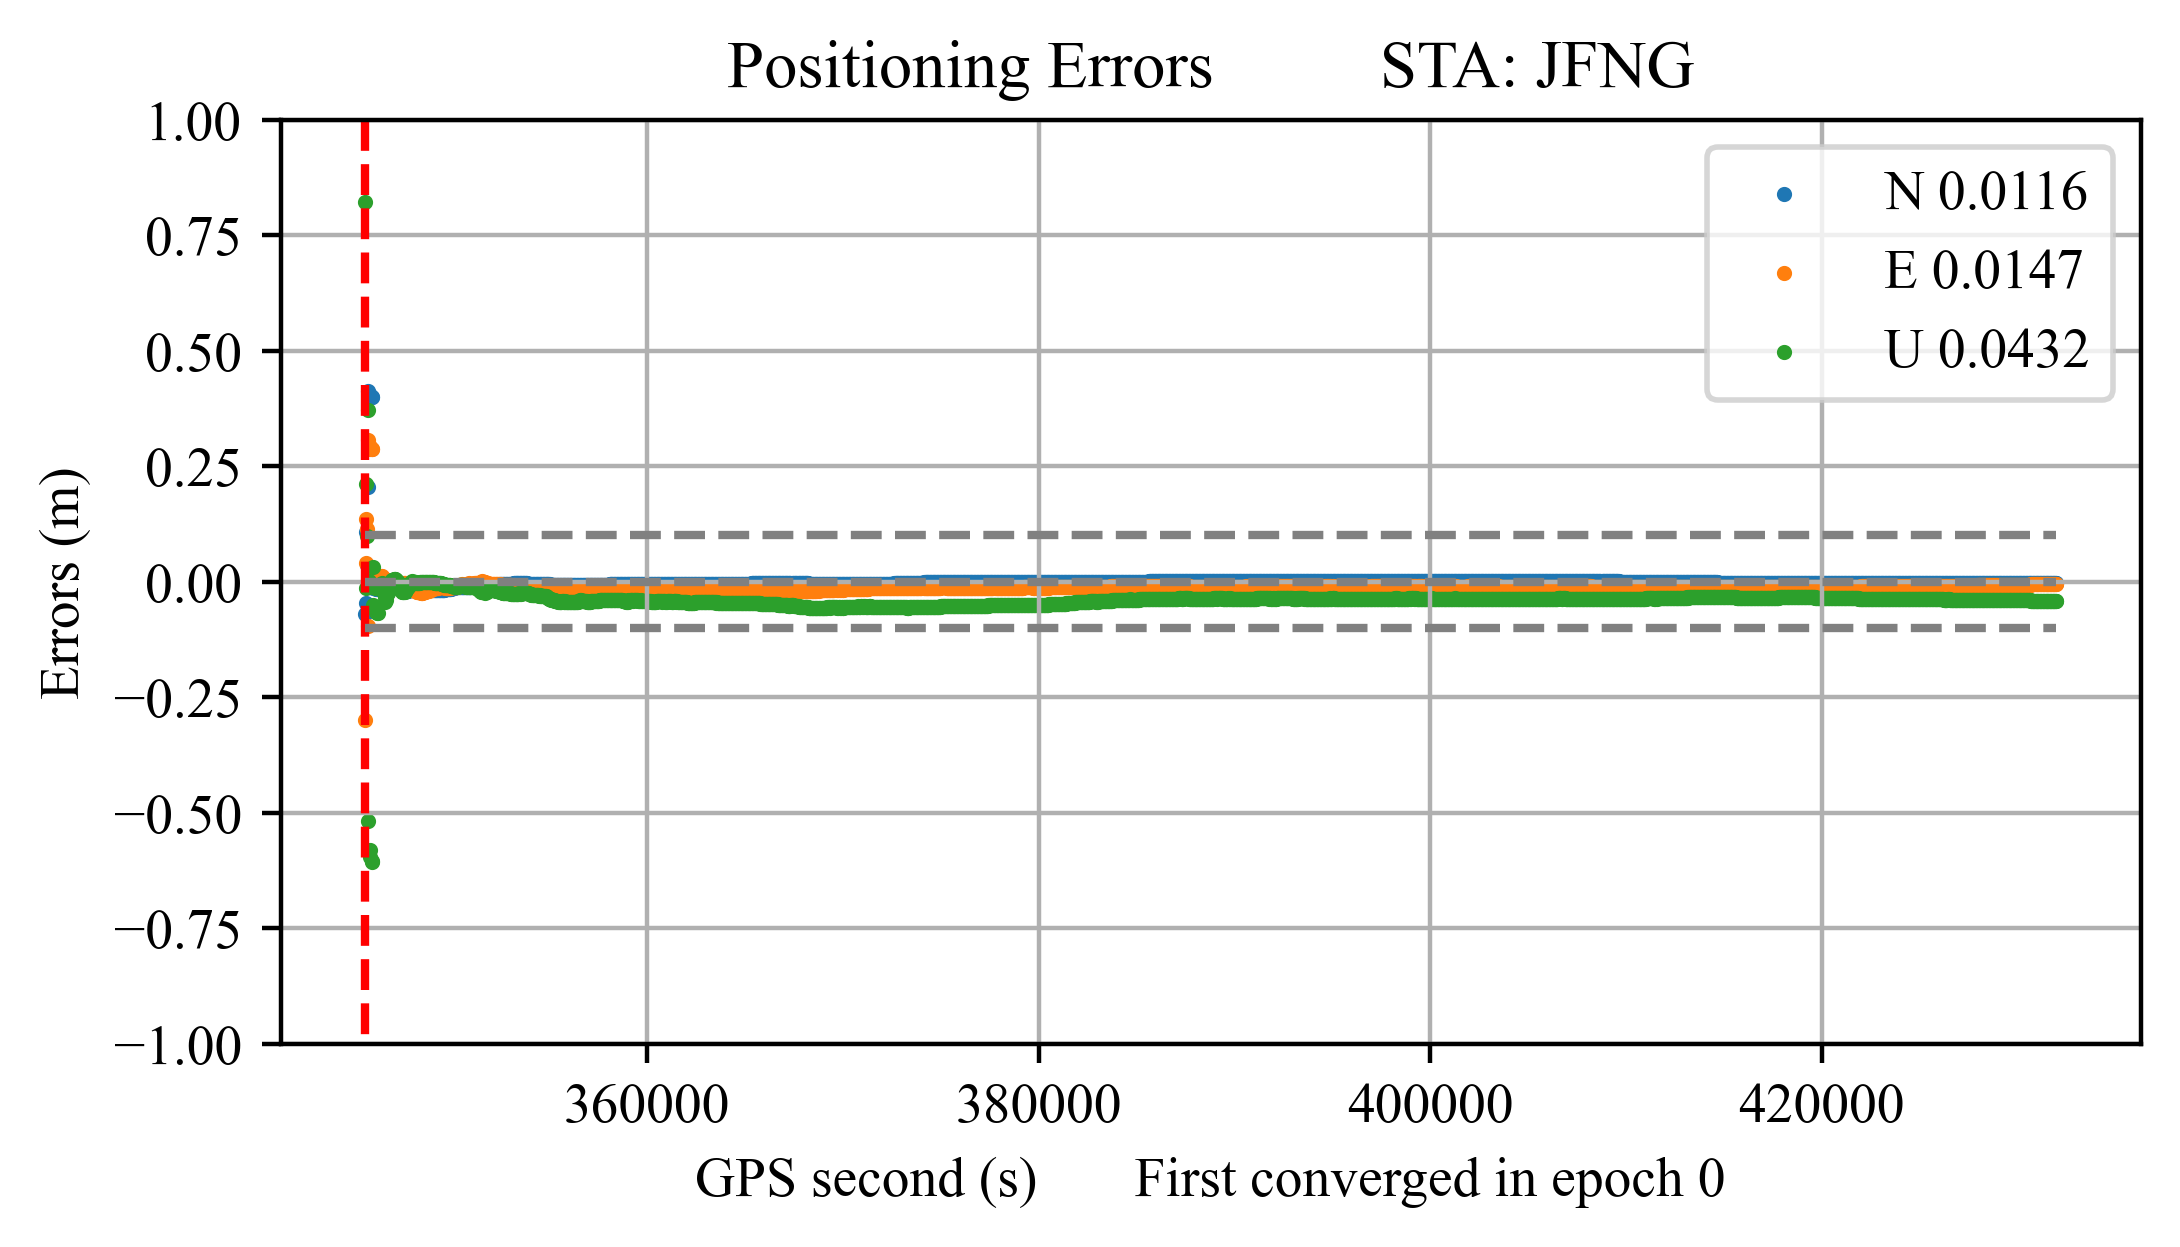

In [8]:
import matplotlib.pyplot as plt

#设置Solution logs文件路径
SNX_CRD_f="data/SNX/IGS0OPSSNX_20231310000_01D_01D_CRD.SNX"
STA_name="JFNG"                                 #解算站点名称, 若空, 自动赋值为解算日志文件的前四位(依据RINEX V3文件命名规则)
ylim=[-1.0,1.0]                                 #误差可视化纵轴范围, 对于RTK而言, ENU误差可视化一般设置为 -1.0m ~ 1.0m 左右较为适宜
STA=[]
sol_log=Out_log_fix
if(STA==[]):
    STA=CRD_SNX2STA(SNX_CRD_f)[STA_name]
sta=Log2sta(sol_log)
neu=[]
for x in sta:
    neu_x=xyz2neu([x[2],x[3],x[4]],STA)
    neu_n=np.linalg.norm(xyz2neu([x[2],x[3],x[4]],STA))
    neu.append([x[0],x[1],neu_x[0],neu_x[1],neu_x[2],neu_n])
neu=np.array(neu)

#计算首次收敛时间
fix_epoch='failed'
for i in range(len(neu)):
    if((abs(neu[i][2])<=0.30 and abs(neu[i][3])<=0.30)):# and abs(neu[i][4])<=0.10)) or ((neu[i][5])<=0.20)):
        fix_epoch=i
        break
print("First converged in epoch {}".format(fix_epoch))


#绘图
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.figure(dpi=400,facecolor="white",figsize=(6,3))
plt.scatter(neu[:,1],neu[:,2],s=3)
plt.scatter(neu[:,1],neu[:,3],s=3)
plt.scatter(neu[:,1],neu[:,4],s=3)
#plt.plot(neu[:,1],neu[:,5])
plt.grid('on')


#绘制收敛点
if(fix_epoch!="failed"):
    plt.plot([neu[fix_epoch][1],neu[fix_epoch][1]],[1.0,-1.0],'--',c="red")

#收敛标准线(-0.1m, 0.1m)
plt.plot([sta[0][1],sta[-1][1]],[0.0,0.0],'--',c='grey')
plt.plot([sta[0][1],sta[-1][1]],[0.1,0.1],'--',c='grey')
plt.plot([sta[0][1],sta[-1][1]],[-0.1,-0.1],'--',c='grey')

if(ylim!=[]):
    plt.ylim(ylim[0],ylim[1])
    
#plt.title("Easy4PPP Positioning Errors          STA: {}".format(STA_name))
plt.title("Positioning Errors          STA: {}".format(STA_name))
plt.xlabel("GPS second (s)       First converged in epoch {}".format(fix_epoch))

plt.ylabel("Errors (m)")
def RMS(X):
    return sqrt(sum(X**2)/len(X))

plt.legend(["N {:.4f}".format(RMS(np.array(neu)[10:,2])),"E {:.4f}".format(RMS(np.array(neu)[10:,3])),"U {:.4f}".format(RMS(np.array(neu)[10:,4]))])
RMS(np.array(neu)[100:2400,2]),RMS(np.array(neu)[10:,3]),RMS(np.array(neu)[:2400,4])

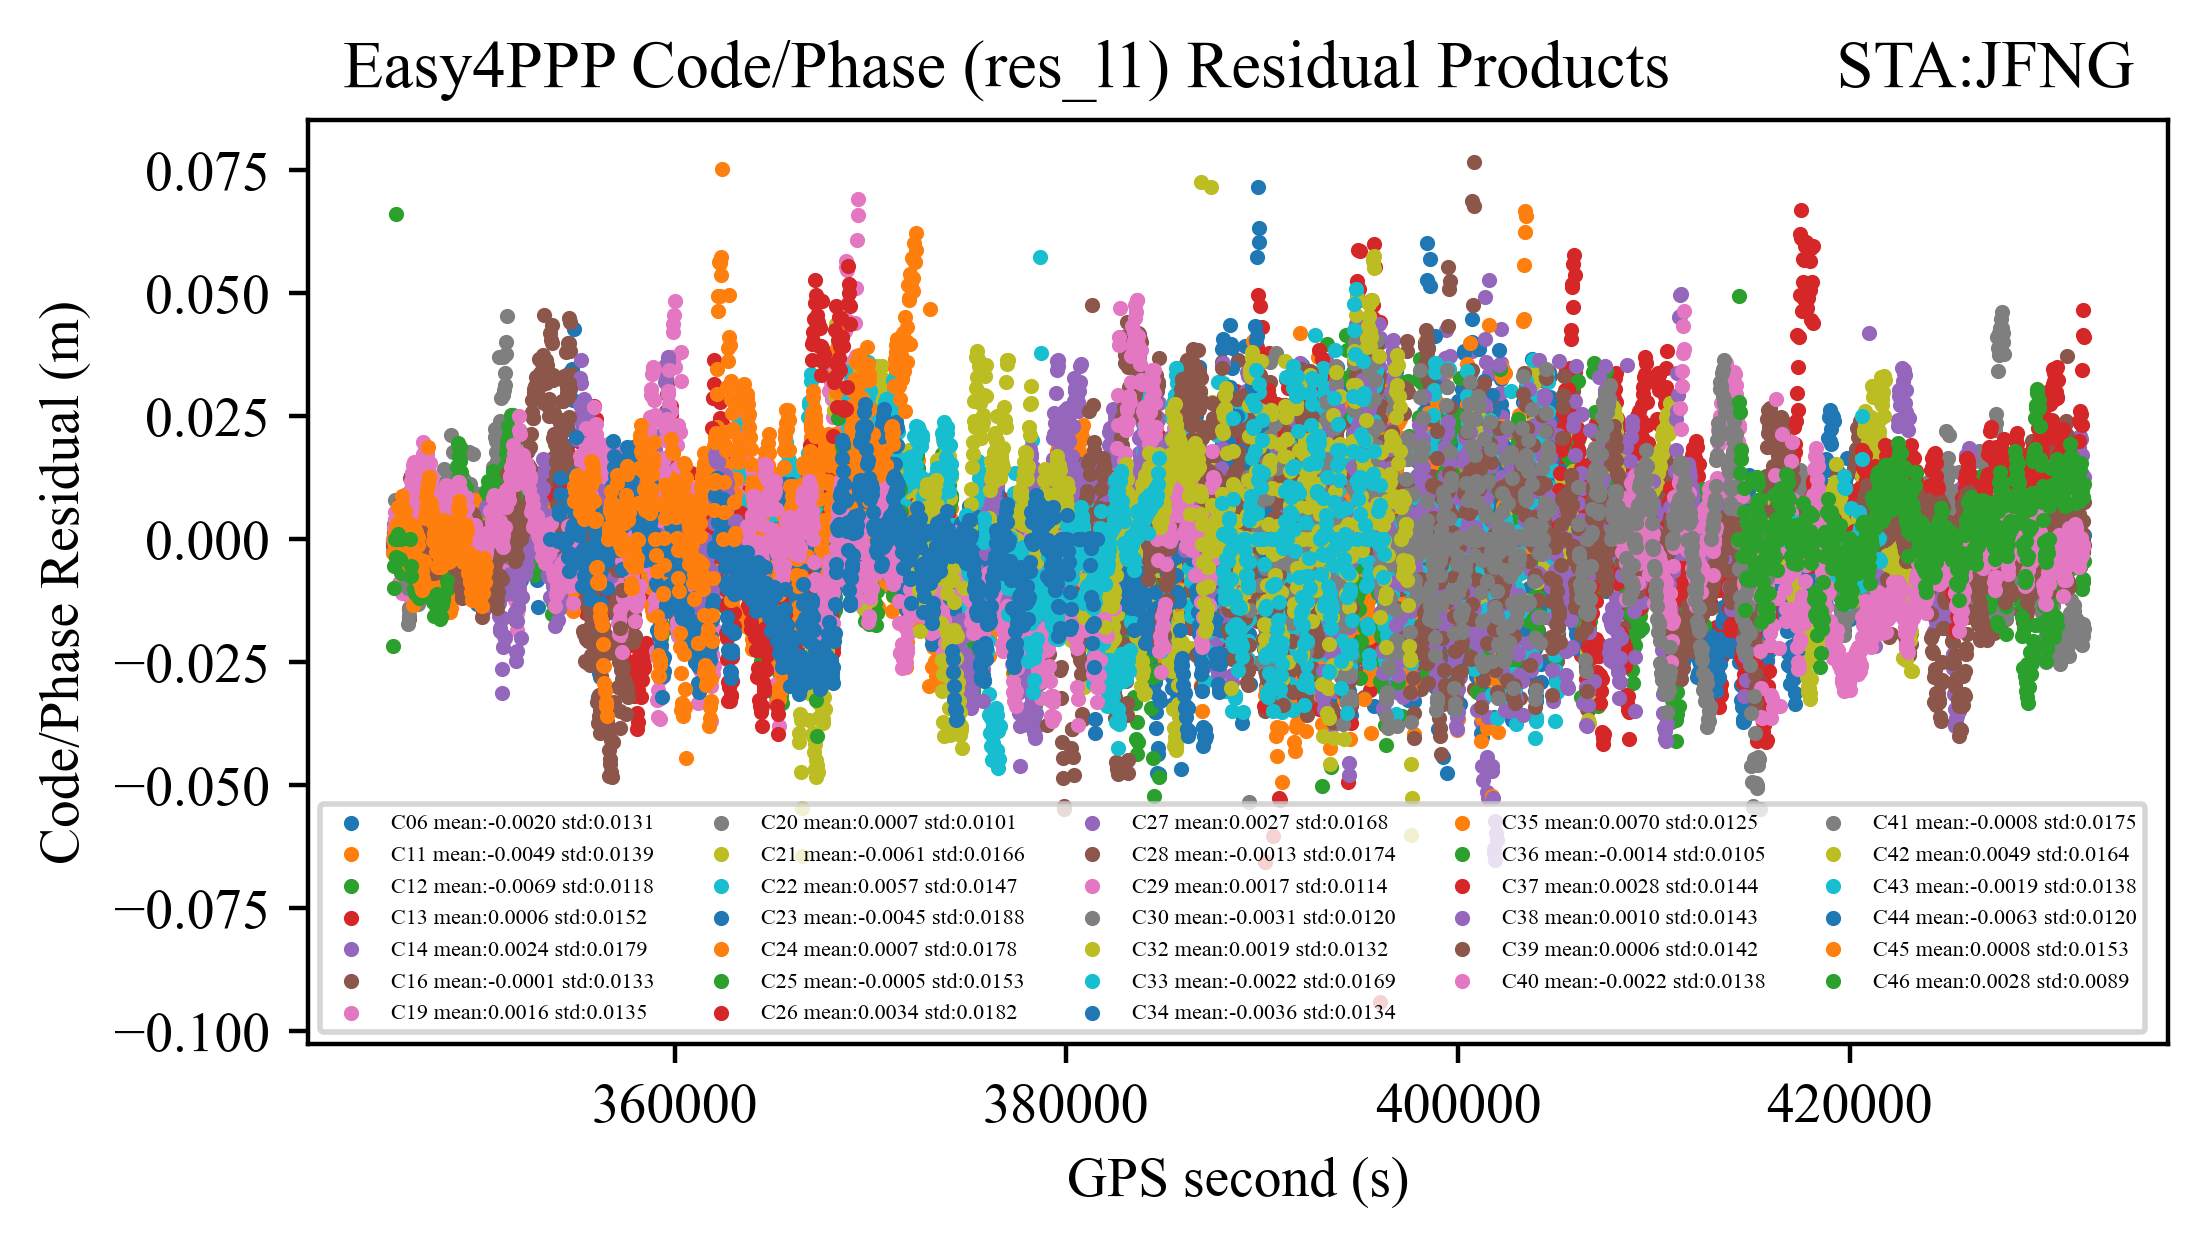

In [9]:
#绘图: 定位残差(NLOS误差)
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Times New Roman']

sys_name='C'        #系统标识符选择: G: GPS; C: BDS
sys_sat_num=65      #系统PRN码最大值: 此选项可限制绘图卫星的最大PRN范围
target='res_l1'     #残差归属: res_p1: 第一频率伪距; res_p2: 第二频率伪距; res_l1: 第一频率载波相位; res_l2: 第二频率载波相位
ylim=[]   #图像纵轴范围, 若空, 则由matplotlib自适应

target_prns=[]
legend=[]
plt.figure(dpi=400,facecolor="white",figsize=(6,3))
for PRN in range(1,sys_sat_num+1):
#for PRN in range(2,3):
    PRN=sys_name+"{:02d}".format(PRN)
    stec_list=[]
    for out in sol_log:
        if(len(target_prns)==0):
            prns=list(out.keys())
        else:
            prns=target_prns.copy()
        if(PRN in prns and PRN in list(out.keys())):
                if(target in list(out[PRN].keys())):
                #print(PRN,list(out[PRN].keys()))
                    GPSsec=out[PRN]['GPSsec']
                    stec_list.append([GPSsec,out[PRN][target]])
    #print(np.array(stec_list))
    
    if(len(stec_list)):
        plt.scatter(np.array(stec_list)[:,0],np.array(stec_list)[:,1],s=3)
        legend.append(PRN+' mean:{:.4f} std:{:.4f}'.format(np.mean(np.array(stec_list)[:,1]), np.std(np.array(stec_list)[:,1]) ) )
        #np.save('resp1_G07.npy',stec_list)

if(ylim!=[]):
    plt.ylim(ylim[0],ylim[1])

plt.ylabel("Code/Phase Residual (m)")
plt.xlabel("GPS second (s)")
plt.title("Easy4PPP Code/Phase ({}) Residual Products          STA:{}".format(target,STA_name))
plt.legend(legend,ncol=5,fontsize=4)

In [10]:
#计算首次固定时间和固定率
first_fix_epoch=-1
fix_counts=0
fix_threshold=10
fix_in=0
for i in range(len(sol_log)):
    try:
        ratio_fix=sol_log[i][list(sol_log[i].keys())[0]]['ratio']
        if(not fix_in):
            t_check=1
            for fix_check in range(fix_threshold):
                if(sol_log[i+fix_check][list(sol_log[i+fix_check].keys())[0]]['ratio']==0.0):
                    t_check=0
            if(t_check):
                first_fix_epoch=i
                fix_in=1
    except:
        continue
    if(fix_in):
        fix_counts+=1
print("Total: {},First Fix Epoch: {}, Fix Rate: {:.3f}".format(len(sol_log),first_fix_epoch,fix_counts*100/(len(sol_log)-first_fix_epoch))) 

Total: 2880,First Fix Epoch: 6, Fix Rate: 100.000


In [11]:
#绘制Mw组合观测值时间序列
#逐历元遍历
Mw_obss=[]
for i in tqdm(range(epoch_start,epoch_start+epoch_length)):
    if(i>=len(br_obs_mats)):
        break
    if(epoch==0):
        #初始化
        rove_rr,rove_obs,rove_satpos=SPPM_form_BRDC([[br_obs_mats[i][1]]],0,GPS_eph,BDS_eph,GAL_eph,sat_out,ion_param,'SF',freqs,el_threthod)
        X,X_time,Pk,Qk,GF_sign,Mw_sign,slip_sign,dN_sign=init_RTK(base_pos,br_obs_mats,i,f1,f2,obs_sys,eph_mode='brdc',spp_brdc=rove_rr,brdc_obs=rove_obs)
        epoch+=1
    #记录流动站当前历元时刻
    rt_week=br_obs_mats[i][1][0]['GPSweek']
    rt_sec=br_obs_mats[i][1][0]['GPSsec']
    rt_unix=gpst2time(rt_week,rt_sec)
    rove_rr,rove_obs,rove_satpos=SPPM_form_BRDC([[br_obs_mats[i][1]]],0,GPS_eph,BDS_eph,GAL_eph,sat_out,ion_param,'SF',freqs,el_threthod)
    if(len(rove_obs)<4):
        print("No valid observation, Pass Week: {}, Sec: {}.".format(rt_week,rt_sec))
        continue
    #状态更新(包括选取可视卫星单差观测值和状态量更新) 
    if(dy_mode=='static'):
        rove_rr=[X[0][0],X[1][0],X[2][0]]
    rnx_sdobs,base_satpos=select_ddsat(br_obs_mats,i,base_pos,rove_rr,rt_unix,f1,f2,rove_obs,rove_satpos_pre=rove_satpos,dsnr_threshold=dsnr_threshold,GPS_eph=GPS_eph,BDS_eph=BDS_eph,GAL_eph=GAL_eph)
    #组合观测值周跳探测
    Mw_sign,slip_sign,dN_sign=update_phase_slip_SF(rnx_sdobs,Mw_sign,slip_sign,Mw_threshold,f1,dN_sign)
    epoch+=1
    Mw_obs={}
    for i in range(len(Mw_sign)):
        if(Mw_sign[i]!=0.0):
            Mw_obs['C{:02d}'.format(i+1)]=[rt_sec,Mw_sign[i]]
    Mw_obss.append(Mw_obs.copy())

100%|██████████| 2880/2880 [00:46<00:00, 61.71it/s]


(-0.5, 10.0)

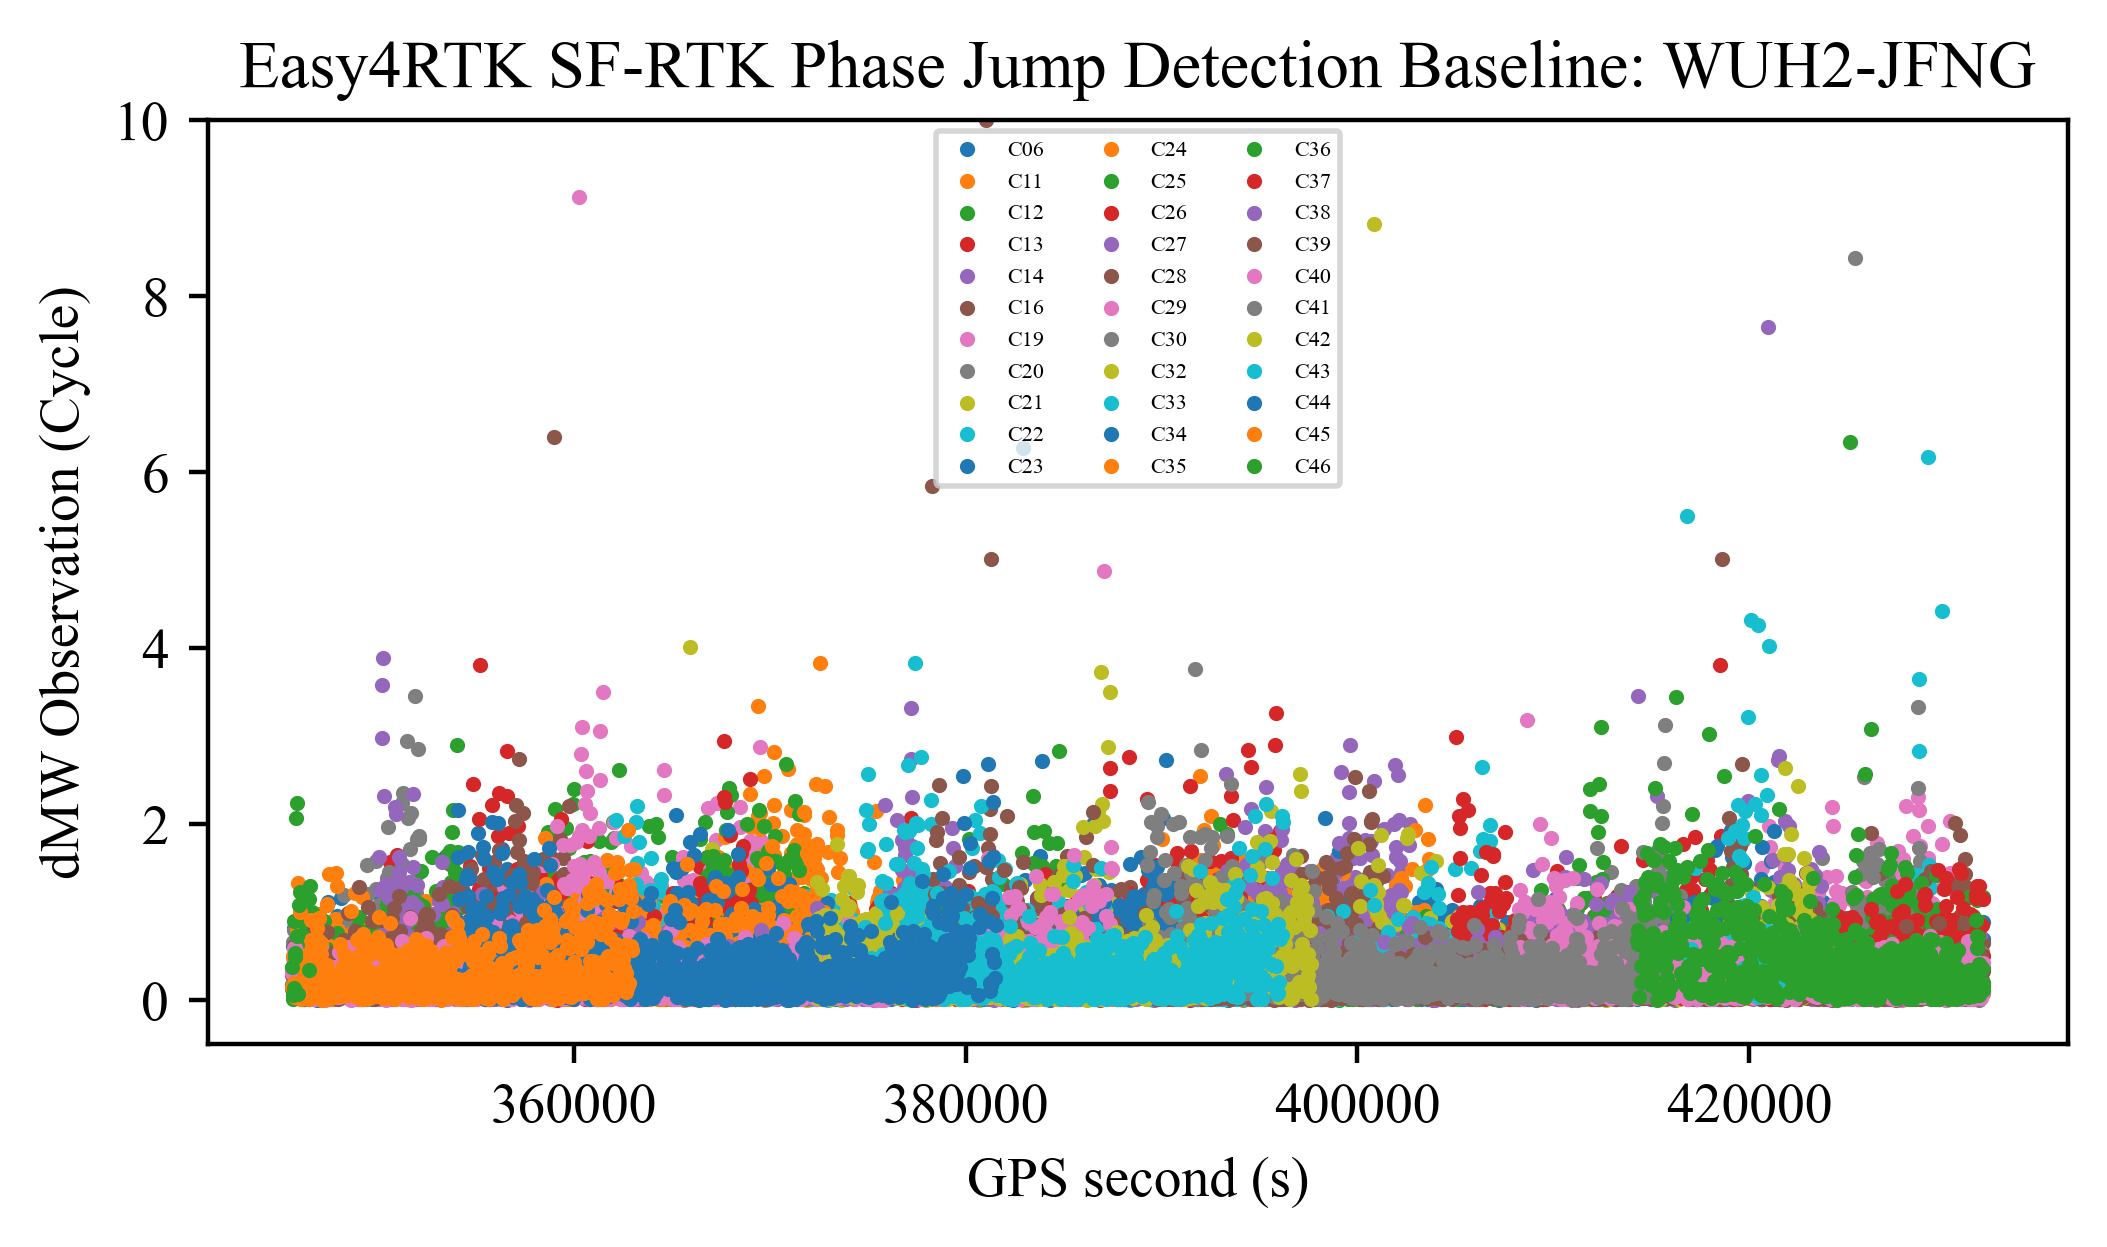

In [12]:
legend=[]
plt.figure(dpi=400,facecolor="white",figsize=(6,3))
for prn in ["C{:02d}".format(t) for t in range(1,66)]:
    Mw_list,Mw_sec=[],[]
    for Mw_obs in Mw_obss:
        if(prn not in Mw_obs.keys()):
            continue
        Mw_sec.append(Mw_obs[prn][0])
        Mw_list.append(Mw_obs[prn][1])
    if(not len(Mw_list)):
        continue
    Mw_list,Mw_sec=np.array(Mw_list),np.array(Mw_sec)
    plt.scatter(Mw_sec[1:],abs(Mw_list[1:]-Mw_list[:-1]),s=3)
    legend.append(prn)
plt.ylabel("dMW Observation (Cycle)")
plt.xlabel("GPS second (s)")
plt.title("Easy4RTK SF-RTK Phase Jump Detection Baseline: WUH2-JFNG")
plt.legend(legend,ncol=3,fontsize=4)
plt.ylim(-0.5,10)